In [1]:
import pandas as pd 
import numpy as np

In [2]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [3]:
r = np.full((20, 1000),fill_value=np.nan)

In [4]:
df = pd.read_csv('ratings_long.csv')

In [5]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [6]:
r

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

r_tf true false matrisi, r_0 Nan'ları 0 ile değiştirdiğimiz matris.

Nan'ları 0 ile dolduruyorum çünkü çarpım/toplama işlemlerinde (mask * (r_0 - pred) gibi) içeride NaN kalsaydı sonuç her yere yayılıp (NaN + herhangi bir sayı = NaN) tüm loss'u NaN yapardı. 0 koymak güvenli, çünkü zaten mask ile o boş hücreleri hataya hiç dahil etmiyorum. 0'ın kendisi hiçbir yerde gerçek puan gibi kullanılmıyor.

In [7]:
r_tf = ~np.isnan(r)
r_0 = np.nan_to_num(r)

u ve v matrislerini ortalaması 0 std 1 olan random sayılar ile üretip küçültüyorum.

In [8]:
u = np.random.randn(20,4) * 0.1
v = np.random.randn(4,1000) * 0.1 

## Loss (Kayıp) Fonksiyonu

Burada amacım, gerçek puanlar ile mu + u @ v ile tahmin ettiğimiz puanlar arasındaki farkı ölçmek (mu = train setindeki gözlemlenen puanların ortalaması, u@v ise bu ortalamadan sapmayı öğreniyor.

Sadece fonksiyona verdiğim mask ile işaretlenen hücreler hataya dahil ediliyor. k-fold içinde bu train_mask ya da test_mask oluyor, ikisi de r_tf'nin, yani gerçekten gözlemlenmiş puanların, bir alt kümesi.

Hatayı n yani maskedeki gözlem sayısıyla bölüyorum ki farklı boyuttaki train/test maskeleri arasında loss karşılaştırılabilir kalsın, sadece toplam kullansaydım daha çok gözlemi olan taraf otomatik olarak daha kötü görünürdü.

In [9]:
def loss(u, v, r_0, mask, mu, lam=0.0):
    n = mask.sum()
    if n == 0:
        return 0.0
    pred = mu + u @ v
    err = mask * (r_0 - pred)
    mse = np.sum(err**2) / n
    reg = lam * (np.sum(u**2) + np.sum(v**2)) / n 
    return mse + reg

## Gradyan Hesabı

Bu fonksiyon ise, loss fonksiyonunun u ve v'ye göre türevini hesaplıyor. Gradient descent algoritması bu türevleri kullanarak u ve v matrislerini adım adım güncelleyip loss'u küçültüyor.

In [10]:
def grad(u, v, r_0, mask, mu, lam=0.0):
    n = mask.sum()
    pred = mu + u @ v
    err = mask * (r_0 - pred)
    du = -2 * (err @ v.T) / n + 2 * lam * u / n
    dv = -2 * (u.T @ err) / n + 2 * lam * v / n
    return du, dv

## Parametre ayarları ve Eğitim (Gradient Descent) ve Farklı λ Değerleri

Aşağıda tanımladığım factorize_eval fonksiyonu, verilen bir train/test maskesiyle u ve v'yi gradient descent ile eğitip her record_every adımda train/test loss geçmişini kaydediyor. Bu fonksiyonu tek bir yerde tanımlayıp hem k-fold içinde parametre aramak için hem de en sonda tüm veriyle final modeli eğitirken tekrar tekrar kullanacağım.

Veri çok seyrek olduğu için tek bir train/test ayrımıyla model eğitmek doğru olmazdı, bu yüzden parametre ayarı yapabilmek için k-fold kullanmaya karar verdim. Böylece tüm veriyi modele sokabileceğim ve eğitirken en iyi parametreleri de k-fold sayesinde öğrenebileceğim. ilk başta lambda ile başlayıp daha sonrasında epoch ve learning rate için de yapacağım.

In [11]:
def factorize_eval(r, r_0, train_mask, test_mask, k=4, n_epoch=20000, lr=0.02, lam=0.1, early_stop=True, tol=1e-3, record_every=100):
    n_users, n_movies = r.shape
    u = np.random.randn(n_users, k) * 0.1
    v = np.random.randn(k, n_movies) * 0.1

    epochs_rec = []
    train_hist = []
    test_hist = []

    
    mu = r_0[train_mask].sum() / train_mask.sum()

    for i in range(n_epoch):
        
        du, dv = grad(u, v, r_0, train_mask, mu, lam)  
        g_norm = np.linalg.norm(du) + np.linalg.norm(dv)

        if g_norm < tol and early_stop:
            break

        u -= lr * du
        v -= lr * dv

        if i % record_every == 0 or i == n_epoch - 1:
            epochs_rec.append(i)
            
            train_hist.append(loss(u, v, r_0, train_mask, mu, lam=0.0))
            
            if test_mask.sum() > 0:
                test_hist.append(loss(u, v, r_0, test_mask, mu, lam=0.0))
            else:
                test_hist.append(0.0)
                
    return u, v, epochs_rec, train_hist, test_hist

5 fold kullandım çünkü veri zaten çok az olduğu için daha fazla fold denemek her fold'u iyice küçültüp val loss'u gürültülü hale getirebilirdi.

random_state=42 koydum ki u,v ve fold'lar her çalıştırmada aynı kalsın, en azından split tarafı tekrarlanabilir olsun.

In [ ]:
from sklearn.model_selection import KFold


    np.random.seed(42)
    
    n_users, n_movies = r.shape
    u = np.random.randn(n_users, k) * 0.1
    v = np.random.randn(k, n_movies) * 0.1


kf = KFold(n_splits=5, shuffle=True, random_state=42)
lambdas = [0.1, 0.01, 0.001, 0.0001]
best_lam = None
min_avg_val_loss = float('inf')


for lam in lambdas:
    val_losses = []
    for train_idx, val_idx in kf.split(obs_rows):
        
        
        t_mask = np.zeros_like(r_tf, dtype=bool)
        v_mask = np.zeros_like(r_tf, dtype=bool)
        t_mask[obs_rows[train_idx], obs_cols[train_idx]] = True
        v_mask[obs_rows[val_idx], obs_cols[val_idx]] = True


        u, v, epochs_rec, train_hist, test_hist = factorize_eval(r, r_0, t_mask, v_mask, lam=lam, record_every=20000)
        val_losses.append(test_hist[-1])

    avg_val_loss = np.mean(val_losses)
    print(f"λ={lam:<8} | 5-Fold Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < min_avg_val_loss:
        min_avg_val_loss = avg_val_loss
        best_lam = lam

print(f"Best params lambda = {best_lam}")

λ=0.1      | 5-Fold Val Loss: 1.8196
λ=0.01     | 5-Fold Val Loss: 1.7506
λ=0.001    | 5-Fold Val Loss: 1.7455
λ=0.0001   | 5-Fold Val Loss: 1.7709
Best params lambda = 0.001


## Learning Rate ve Epoch Sayısı için Grid Search

En iyi lambda'yı bulduktan sonra onu sabit tutup learning rate ve epoch sayısı için de aynı 5-fold mantığıyla küçük bir grid search yapıyorum. Amaç kocaman bir arama yapmak değil, birkaç makul değeri deneyip hangi kombinasyonun validation loss'unu en çok düşürdüğünü görmek yukarıdaki ile aynı mantıkla

learning rate'leri ne çok ıraksayacak ne de çok yakınsayacak şekilde seçmemeye makul tutmaya çalıştım.

record_every=max(n_epoch, 1)  yazmamın sebebi: burada sadece test_hist[-1]'i (son kaydedilen değeri) kullanıyorum, ara adımların loss'unu grafikte göstermeyeceğim; bu yüzden record_every'yi epoch sayısına eşitleyip sadece başlangıç (i=0) ve bitiş (i=n_epoch-1) adımlarını kaydettiriyorum, gereksiz hesaplamadan kaçınmış oluyorum.

In [13]:
learning_rates = [0.01, 0.02, 0.05]
epoch_counts = [5000, 10000, 20000]

best_lr = None
best_epoch = None
min_avg_val_loss_lr = float('inf')

for lr in learning_rates:
    for n_epoch in epoch_counts:
        val_losses = []
        for train_idx, val_idx in kf.split(obs_rows):
            t_mask = np.zeros_like(r_tf, dtype=bool)
            v_mask = np.zeros_like(r_tf, dtype=bool)
            t_mask[obs_rows[train_idx], obs_cols[train_idx]] = True
            v_mask[obs_rows[val_idx], obs_cols[val_idx]] = True

            u, v, epochs_rec, train_hist, test_hist = factorize_eval(
                r, r_0, t_mask, v_mask,
                lam=best_lam, lr=lr, n_epoch=n_epoch,
                record_every=max(n_epoch, 1)
            )
            val_losses.append(test_hist[-1])

        avg_val_loss = np.mean(val_losses)
        print(f"lr={lr:<5} epoch={n_epoch:<6} | 5-Fold Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < min_avg_val_loss_lr:
            min_avg_val_loss_lr = avg_val_loss
            best_lr = lr
            best_epoch = n_epoch

print(f"Best params -> lr = {best_lr}, epoch = {best_epoch}")

lr=0.01  epoch=5000   | 5-Fold Val Loss: 1.7436
lr=0.01  epoch=10000  | 5-Fold Val Loss: 1.8201
lr=0.01  epoch=20000  | 5-Fold Val Loss: 1.7668
lr=0.02  epoch=5000   | 5-Fold Val Loss: 1.9215
lr=0.02  epoch=10000  | 5-Fold Val Loss: 1.8574
lr=0.02  epoch=20000  | 5-Fold Val Loss: 1.7085
lr=0.05  epoch=5000   | 5-Fold Val Loss: 1.6913
lr=0.05  epoch=10000  | 5-Fold Val Loss: 1.7505
lr=0.05  epoch=20000  | 5-Fold Val Loss: 1.7507
Best params -> lr = 0.05, epoch = 5000


En iyi lambda/lr/epoch'u bulduktan sonra artık elimde ayrı bir test/validation setine ihtiyacım yok. amaç en iyi hiperparametrelerle mümkün olan en iyi final modeli elde etmek olduğu için tüm gözlemlenen 200 puanı train_mask_final = r_tf eğitim için kullanıyorum, test_mask_empty`de tamamen boş hiç val verisi ayırmıyorum.

Bunun bir bedeli var: u ve v toplamda 4080 parametre, ama elimde sadece 200 gözlem var. Yani model kolayca ezberleyebilir. Aşağıda train RMSE 0.02 çıkıyor, CV'den beklediğim RMSE 1.3 iken, bu final train loss'unun düşük olması gerçek performansın iyi olduğu anlamına gelmiyor, sadece modelin gördüğü 200 noktayı ezberlediğini gösteriyor. Gerçek performans tahminim hâlâ aslında k-fold'da gelen ortalama hata

In [14]:
train_mask_final = np.zeros_like(r_tf, dtype=bool)
train_mask_final[r_tf] = True
test_mask_empty = np.zeros_like(r_tf, dtype=bool)

u_final, v_final, epochs_rec, train_hist, _ = factorize_eval(
    r, r_0, train_mask_final, test_mask_empty,
    lam=best_lam, lr=best_lr, n_epoch=best_epoch, record_every=100
)

val_loss_estimate = min_avg_val_loss_lr

print(f"Final Train {train_mask_final.sum()} ")
print(f"Son Train Loss: {train_hist[-1]:.4f} -> RMSE: {np.sqrt(train_hist[-1]):.4f}")

Final Train 200 
Son Train Loss: 0.0004 -> RMSE: 0.0193


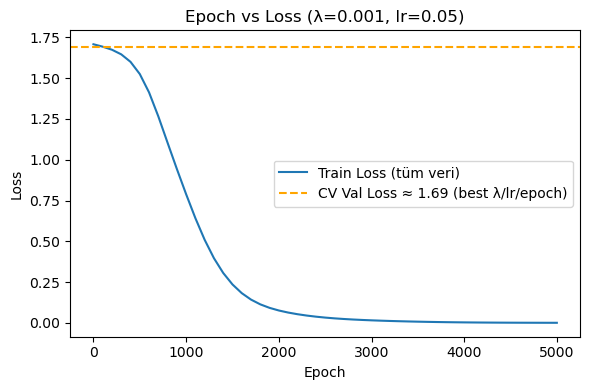

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(epochs_rec, train_hist, label="Train Loss (tüm veri)")
plt.axhline(val_loss_estimate, color="orange", linestyle="--",
            label=f"CV Val Loss ≈ {val_loss_estimate:.2f} (best λ/lr/epoch)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Epoch vs Loss (λ={best_lam}, lr={best_lr})")
plt.legend()
plt.tight_layout()
plt.show()

val_loss_estimate olarak kullandığım değer, learning rate/epoch aramasında bulduğum en düşük ortalama CV val loss'u yani aynı CV sonuçlarını hem hiperparametre seçmek hem de gerçek performans olarak raporlamak için kullanmış oluyorum.

In [16]:
final_train_loss = train_hist[-1]
train_rmse = np.sqrt(final_train_loss)
val_rmse_estimate = np.sqrt(val_loss_estimate)

print(f"Son Train Loss: {final_train_loss:.4f}  ->  Train RMSE: {train_rmse:.4f}")
print(f"CV Val Loss   : {val_loss_estimate:.4f}  ->  CV Val RMSE : {val_rmse_estimate:.4f}")

Son Train Loss: 0.0004  ->  Train RMSE: 0.0193
CV Val Loss   : 1.6913  ->  CV Val RMSE : 1.3005
